In [123]:
import pandas as pd
import requests
from io import StringIO

url = "https://mnre.gov.in/en/year-wise-achievement/"
response = requests.get(url)
response.raise_for_status()

tables = pd.read_html(StringIO(response.text))
df = tables[0]   # that main table

# Step 1: Rename columns to match your desired names
new_cols = [
    "Sector",
    "Cum_2014",
    "2014-15",
    "2015-16",
    "2016-17",
    "2017-18",
    "2018-19",
    "2019-20",
    "2020-21",
    "2021-22",
    "2022-23",
    "2023-24",
    "2024-25",
    "2025-26",
    "Cum_2026"
]
df.columns = new_cols

# Step 2: Make sure the last row is "Total"
df.iloc[-1, 0] = "Total"

# Step 3: Convert all numeric columns to float
for col in df.columns[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Step 4: Convert to your exact dict format
sector_order = [
    'Wind Power',
    'Solar Power',
    'Small Hydro Power',
    'Biomass (Bagasse) Cogeneration',
    'Biomass(Non-bagasse) Cogeneration',
    'Waste to Energy',
    'Waste to Energy (Off-grid)',
    'Total'
]

data = {'Sector': sector_order}
for year in df.columns[1:]:
    data[year] = [float(df.loc[df["Sector"] == s, year].iloc[0]) for s in sector_order]

# Now `data` looks exactly like your example
print(data)

{'Sector': ['Wind Power', 'Solar Power', 'Small Hydro Power', 'Biomass (Bagasse) Cogeneration', 'Biomass(Non-bagasse) Cogeneration', 'Waste to Energy', 'Waste to Energy (Off-grid)', 'Total'], 'Cum_2014': [21042.58, 2821.91, 3803.68, 7419.23, 531.82, 90.58, 139.79, 35849.59], '2014-15': [2311.77, 1171.62, 251.68, 295.67, 60.05, 0.0, 9.71, 4100.5], '2015-16': [3423.05, 3130.36, 218.11, 304.85, 59.24, 0.0, 5.69, 7141.3], '2016-17': [5502.37, 5658.63, 106.38, 161.95, 2.2, 23.5, 11.77, 11466.81], '2017-18': [1865.23, 9563.69, 105.95, 519.1, 9.5, 24.22, 5.55, 12093.24], '2018-19': [1480.97, 6750.97, 107.34, 402.7, 12.0, 0.0, 6.58, 8760.56], '2019-20': [2117.79, 6510.06, 90.01, 97.0, 0.0, 9.34, 19.11, 8843.31], '2020-21': [1503.3, 5628.8, 103.65, 173.37, 97.24, 21.0, 20.75, 7548.11], '2021-22': [1110.53, 12760.5, 62.09, 59.69, 0.0, 54.5, 34.66, 14081.97], '2022-23': [2275.55, 12783.8, 95.4, 0.0, 42.4, 25.0, 52.28, 15274.43], '2023-24': [3253.38, 15033.24, 58.95, 0.0, 107.34, 1.6, 30.17, 18484

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.DataFrame(data)

# 2. Years list
years = ['2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']

# 3. Function to calculate cumulative capacity for each year
def calculate_cumulative(row):
    cum = row['Cum_2014']
    cumulatives = [cum]
    
    # Add annual additions
    addition_cols = ['2014-15', '2015-16', '2016-17', '2017-18', '2018-19', 
                    '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
    
    for col in addition_cols:
        cum += row[col]
        cumulatives.append(cum)
    
    return cumulatives

# 4. Calculate cumulative for key sectors only (Wind + Solar + Total)
key_sectors = ['Wind Power', 'Solar Power', 'Total']
df_key = df[df['Sector'].isin(key_sectors)].copy()

df_key['cumulatives'] = df_key.apply(calculate_cumulative, axis=1)

# 5. Create long format for plotting (convert GW)
plot_data = []
for idx, row in df_key.iterrows():
    sector = row['Sector']
    cums = row['cumulatives']
    for i, cap in enumerate(cums):
        plot_data.append({'Year': years[i], 'Capacity_GW': cap/1000, 'Sector': sector})

df_plot = pd.DataFrame(plot_data)


In [125]:
df

,Sector,Cum_2014,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26,Cum_2026
0,Wind Power,21042.58,2311.77,3423.05,5502.37,1865.23,1480.97,2117.79,1503.30,1110.53,2275.55,3253.38,4151.31,6057.02,56094.84
1,Solar Power,2821.91,1171.62,3130.36,5658.63,9563.69,6750.97,6510.06,5628.80,12760.50,12783.80,15033.24,23832.87,44614.25,150260.70
2,Small Hydro Power,3803.68,251.68,218.11,106.38,105.95,107.34,90.01,103.65,62.09,95.40,58.95,97.30,70.81,5171.36
3,Biomass (Bagasse) Cogeneration,7419.23,295.67,304.85,161.95,519.10,402.70,97.00,173.37,59.69,0.00,0.00,387.76,0.00,9821.32
4,Biomass(Non-bagasse) Cogeneration,531.82,60.05,59.24,2.20,9.50,12.00,0.00,97.24,0.00,42.40,107.34,0.00,126.06,1047.85
5,Waste to Energy,90.58,0.00,0.00,23.50,24.22,0.00,9.34,21.00,54.50,25.00,1.60,59.60,14.90,324.24
6,Waste to Energy (Off-grid),139.79,9.71,5.69,11.77,5.55,6.58,19.11,20.75,34.66,52.28,30.17,194.81,22.24,553.12
7,Total,35849.59,4100.50,7141.30,11466.81,12093.24,8760.56,8843.31,7548.11,14081.97,15274.43,18484.68,28723.65,50905.28,223273.43


In [126]:
df.dtypes

Sector          str
Cum_2014    float64
2014-15     float64
2015-16     float64
2016-17     float64
2017-18     float64
2018-19     float64
2019-20     float64
2020-21     float64
2021-22     float64
2022-23     float64
2023-24     float64
2024-25     float64
2025-26     float64
Cum_2026    float64
dtype: object

In [127]:
df.isnull().sum()

Sector      0
Cum_2014    0
2014-15     0
2015-16     0
2016-17     0
2017-18     0
2018-19     0
2019-20     0
2020-21     0
2021-22     0
2022-23     0
2023-24     0
2024-25     0
2025-26     0
Cum_2026    0
dtype: int64

In [128]:
df.shape

(8, 15)

total 13 years are considered for 8 sources of renewable energy

In [129]:
df.describe().round(2)

,Cum_2014,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26,Cum_2026
count,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
mean,8962.40,1025.12,1785.32,2866.70,3023.31,2190.14,2210.83,1887.03,3520.49,3818.61,4621.17,7180.91,12726.32,55818.36
std,12890.60,1477.38,2595.59,4277.49,4904.05,3511.54,3504.81,2987.63,6132.19,6383.82,7629.27,11940.12,21787.33,85168.01
min,90.58,0.00,0.00,2.20,5.55,0.00,0.00,20.75,0.00,0.00,0.00,0.00,0.00,324.24
25%,433.81,47.46,45.85,20.57,20.54,10.64,16.67,78.18,49.54,38.05,23.03,87.88,20.40,924.17
50%,3312.80,273.68,261.48,134.16,312.52,255.02,93.50,138.51,60.89,73.84,83.15,291.28,98.44,7496.34
75%,10825.07,1456.66,3203.53,5541.44,3789.84,2798.47,3215.86,2534.68,4023.02,4902.61,6198.34,9071.70,15696.33,79636.30
max,35849.59,4100.50,7141.30,11466.81,12093.24,8760.56,8843.31,7548.11,14081.97,15274.43,18484.68,28723.65,50905.28,223273.43


In [130]:
cf = df.iloc[:,1:]

In [131]:
cf.T.corr(numeric_only = True)

,0,1,2,3,4,5,6,7
0,1.000000,0.894701,0.943432,0.937077,0.980066,0.965552,0.938761,0.959665
1,0.894701,1.000000,0.713101,0.702987,0.833041,0.912575,0.908019,0.984024
2,0.943432,0.713101,1.000000,0.998696,0.971089,0.885205,0.846511,0.825245
3,0.937077,0.702987,0.998696,1.000000,0.963868,0.882041,0.844274,0.816656
4,0.980066,0.833041,0.971089,0.963868,1.000000,0.924169,0.891085,0.914452
5,0.965552,0.912575,0.885205,0.882041,0.924169,1.000000,0.971937,0.958108
6,0.938761,0.908019,0.846511,0.844274,0.891085,0.971937,1.000000,0.944708
7,0.959665,0.984024,0.825245,0.816656,0.914452,0.958108,0.944708,1.000000


The correlation is high for all , implying that the growth generally happened altogether for all the sources

In [132]:
df.skew(numeric_only = True)

Cum_2014    1.675644
2014-15     1.615323
2015-16     1.491271
2016-17     1.376464
2017-18     1.456712
2018-19     1.461173
2019-20     1.416832
2020-21     1.459405
2021-22     1.439377
2022-23     1.428532
2023-24     1.419685
2024-25     1.437420
2025-26     1.428940
Cum_2026    1.482059
dtype: float64

Skewness > 1 means the data is heavily uneven, with dominance by a small number of values, i.e some sources like solar, wind

In [133]:
df.kurtosis(numeric_only = True)

Cum_2014    2.095199
2014-15     1.999671
2015-16     1.696677
2016-17     1.132225
2017-18     0.409560
2018-19     0.497948
2019-20     0.524727
2020-21     0.592666
2021-22     0.069929
2022-23     0.200081
2023-24     0.251107
2024-25     0.238378
2025-26     0.105846
Cum_2026    0.995583
dtype: float64

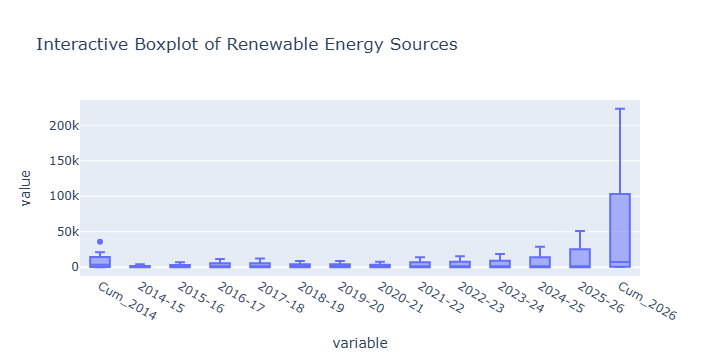

In [134]:
import plotly.express as px

num_df = df.select_dtypes(include="number")

fig = px.box(
    num_df,
    title="Interactive Boxplot of Renewable Energy Sources",
)

fig.show()

In [44]:
import sys
print(sys.executable)

C:\Users\POOJA DANGE\AppData\Local\Programs\Python\Python314\python.exe


In [45]:
pip install pdfplumber

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\POOJA DANGE\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


In [46]:
import os
print(os.listdir("."))  # lists files in current folder

['.ipynb_checkpoints', '2k25.ipynb', 'Demand.xlsx', 'electricity_data_processed.csv', 'electricity_growth_long.csv', 'generation.ipynb', 'generation2.ipynb', 'Indian_States.txt', 'india_telengana.geojson.txt', 'last.ipynb', 'Model.ipynb', 'Plot1.ipynb', 'plots2.ipynb', 'plots3.ipynb', 'power.xlsx', 'renewable_31032026.csv', 'renewable_31032026.xlsx', 'renewable_31032026_raw_text.txt', 'Requirement.xlsx', 'stateplot.ipynb', 'state_wise.pdf', 'style_loader.py', 'Untitled.ipynb', '~$power.xlsx']


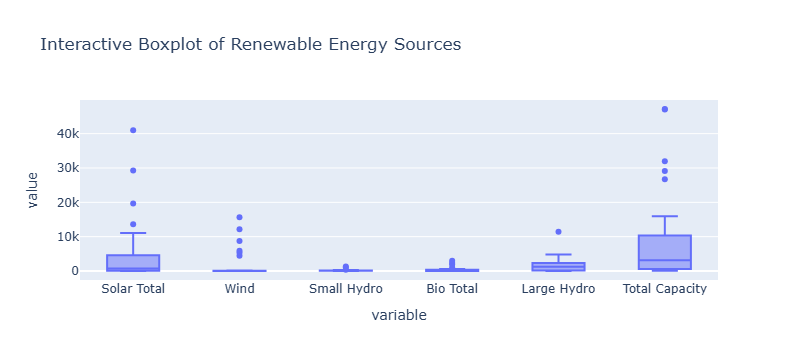

In [135]:
import plotly.express as px

num_df = df_state.select_dtypes(include="number")

fig = px.box(
    num_df,
    title="Interactive Boxplot of Renewable Energy Sources",
)

fig.show()

In [95]:


import io
import re
import requests
import pdfplumber
import pandas as pd

# ── Config ─────
PDF_URL = (
    "https://cdnbbsr.s3waas.gov.in/"
    "s3716e1b8c6cd17b771da77391355749f3/uploads/2026/04/20260415955675604.pdf"
)

# PDF column order (what pdfplumber sees left-to-right):
PDF_COLS = [
    "small_hydro", "wind",
    "bagasse", "nonbagasse", "wte", "wte_offgrid", "bio_total",
    "gm_solar", "rts", "hybrid", "offgrid_solar", "solar_total",
    "large_hydro", "total",
]

# Output column order for raw_text (matches the format you want):
OUT_COLS = PDF_COLS

# Regex: <int>  <int>  <state name (words/&/spaces)>  <numbers...>
ROW_RE = re.compile(
    r"^(\d+)\s+(\d+)\s+([A-Za-z &]+?)\s+([\d.][0-9. ]+)$"
)


# ── Step 1: Download ───

def download_pdf(url: str) -> io.BytesIO:
    print(f"[1] Downloading PDF …")
    resp = requests.get(url, timeout=30, headers={"User-Agent": "Mozilla/5.0"})
    resp.raise_for_status()
    print(f"    {len(resp.content)/1024:.1f} KB received")
    return io.BytesIO(resp.content)


# ── Step 2: Extract raw text ────

def extract_text(pdf_bytes: io.BytesIO) -> str:
    print("[2] Extracting text with pdfplumber …")
    with pdfplumber.open(pdf_bytes) as pdf:
        text = pdf.pages[0].extract_text(x_tolerance=3, y_tolerance=3)
    print(f"    {len(text.splitlines())} lines extracted")
    return text


# ── Step 3: Constraint-based token alignment ──

def align_tokens(tokens: list[str], s_no: int, state: str) -> list[float] | None:
    t = [float(x) for x in tokens]
    tot = t[-1]

    for lh_present in [True, False]:
        # Set right_used inside the loop (not before it)
        if lh_present:
            if len(t) < 3:
                continue
            lh = t[-2]
            st = t[-3]
            right_used = 3
        else:
            if len(t) < 2:
                continue
            lh = 0.0
            st = t[-2]
            right_used = 2

        # Now use right_used safely
        if len(t) < right_used + 1:
            continue

        left = t[:len(t) - right_used]
        rem  = tot - lh - st
        if rem < -0.02:
            continue

        # --- rest of the function remains unchanged ---
        # (solar block, bio block, etc.)

        for sol_size in [4, 3, 2]:
            if len(left) < sol_size:
                continue
            sol_block = left[-sol_size:]
            pre_sol   = left[:-sol_size]
            if abs(sum(sol_block) - st) > 0.02:
                continue
            if not pre_sol:
                continue

            bio_total_val = pre_sol[-1]
            pre_bio       = pre_sol[:-1]

            for bio_sub_size in [4, 3, 2, 1, 0]:
                if len(pre_bio) < bio_sub_size:
                    continue
                bio_sub  = pre_bio[-bio_sub_size:] if bio_sub_size > 0 else []
                pre_bio2 = pre_bio[:-bio_sub_size] if bio_sub_size > 0 else pre_bio

                if bio_sub_size > 0 and abs(sum(bio_sub) - bio_total_val) > 0.02:
                    continue
                if bio_sub_size == 0 and abs(bio_total_val) > 0.02:
                    continue

                if   len(pre_bio2) == 0: sh, wind = 0.0, 0.0
                elif len(pre_bio2) == 1: sh, wind = pre_bio2[0], 0.0
                elif len(pre_bio2) == 2: sh, wind = pre_bio2[0], pre_bio2[1]
                else: continue

                if abs(sh + wind + bio_total_val - rem) > 0.02:
                    continue

                # Expand bio block → [bagasse, nonbagasse, wte, wte_offgrid]
                b4 = [0.0] * 4
                for i, v in enumerate(bio_sub):
                    b4[i + (4 - bio_sub_size)] = v

                # Expand solar block → [gm_solar, rts, hybrid, offgrid_solar]
                # hybrid (index 2) is the column most often absent
                s4 = [0.0] * 4
                if   sol_size == 4: s4 = list(sol_block)
                elif sol_size == 3: s4[0], s4[1], s4[3] = sol_block[0], sol_block[1], sol_block[2]
                elif sol_size == 2: s4[0], s4[3]         = sol_block[0], sol_block[1]

                # Return in PDF column order
                return [sh, wind] + b4 + [bio_total_val] + s4 + [st, lh, tot]

    return None   # alignment failed


# ── Step 4: Parse text → DataFrame ───────────────────────────────────────────

def parse(raw_text: str) -> pd.DataFrame:
    print("[3] Parsing and aligning rows …")
    records  = []
    failed   = []

    for line in raw_text.splitlines():
        line = line.strip()
        m    = ROW_RE.match(line)
        if not m:
            continue

        s_no     = int(m.group(1))
        lgd_code = int(m.group(2))
        state    = m.group(3).strip()
        tokens   = m.group(4).strip().split()

        aligned = align_tokens(tokens, s_no, state)
        if aligned is None:
            failed.append(f"  ✗ Row {s_no} ({state}): could not align {tokens}")
            continue

        records.append([s_no, lgd_code, state] + aligned)

    if failed:
        print("  Alignment failures:")
        print("\n".join(failed))

    print(f"    {len(records)} rows aligned successfully  |  {len(failed)} failures")
    return pd.DataFrame(records, columns=["s_no", "lgd_code", "state"] + PDF_COLS)


# ── Step 5: Build raw_text string ─────────────────────────────────────────────

def to_raw_text(df: pd.DataFrame) -> str:
    """
    Format the DataFrame as the raw_text string:
        s_no  lgd_code  state  large_hydro  small_hydro  wind  ...  total
    Whole numbers are emitted without decimals (218 not 218.0).
    """
    def fmt(v: float) -> str:
        if v == 0:          return "0"
        if v == int(v):     return str(int(v))
        return str(v)

    lines = []
    for _, row in df.sort_values("s_no").iterrows():
        parts = (
            [str(int(row["s_no"])), str(int(row["lgd_code"])), row["state"]]
            + [fmt(row[c]) for c in OUT_COLS]
        )
        lines.append(" ".join(parts))
    return "\n".join(lines)


# ── Main ──────────────────────────────────────────────────────────────────────

    
def maini():
    # pdf_bytes = download_pdf(PDF_URL)
    raw_text_pdf = extract_text("state_wise.pdf")
    df = parse(raw_text_pdf)

    raw_text = to_raw_text(df)
    return raw_text



raw_text = maini()

[2] Extracting text with pdfplumber …
    57 lines extracted
[3] Parsing and aligning rows …
  Alignment failures:
  ✗ Row 33 (Haveli and Daman &): could not align ['134.90', '138.65']
    35 rows aligned successfully  |  1 failures


In [96]:
print(raw_text)

1 28 Andhra Pradesh 164.51 4415.78 378.1 134.57 53.16 49.19 615.02 6382.54 774.5 249.42 88.34 7494.8 3290 15980.11
2 12 Arunachal Pradesh 140.61 0 0 0 0 0 0 1.27 6.68 0 7.49 15.44 1865 2021.05
3 18 Assam 34.11 0 0 0 0 8 8 216.26 344.2 0 9.71 570.17 346 958.28
4 10 Bihar 70.7 0 0 112.5 31.4 1.32 145.22 196.06 218 0 21.28 435.34 0 651.26
5 22 Chhattisgarh 100.9 0 0 272.09 7 10.83 289.92 1254.41 167.6 0 390.73 1812.74 120 2323.56
6 30 Goa 0.05 0 0 0 0 1.94 1.94 8.51 71.5 0 1.49 81.5 0 83.49
7 24 Gujarat 113.3 15642.26 65.3 12 7.5 45.05 129.85 20974.68 6881.8 1273.43 173.01 29302.92 1990 47178.33
8 6 Haryana 73.5 0 151.4 125.46 11.2 41.78 329.84 267.76 1188.3 0 1152.32 2608.38 0 3011.72
9 2 Himachal Pradesh 1013.46 0 0 0 9.2 1 10.2 257 66.7 0 34.58 358.28 11421.02 12802.96
10 1 Jammu & Kashmir 189.93 0 0 0 0 5 5 2.49 42.2 0 34.79 79.48 3360 3634.41
11 20 Jharkhand 4.05 0 0 0 19.1 1.04 20.14 21 94.9 0 139.5 255.4 210 489.59
12 29 Karnataka 1284.73 8730.14 1868.91 20.2 1 26.94 1917.05 9855.7

In [97]:
lines = raw_text.split("\n")
clean_lines = []
buffer = ""

for line in lines:
    line = line.strip()
    if not line:
        continue

    if re.match(r"^\d+", line):
        if buffer:
            clean_lines.append(buffer)
        buffer = line
    else:
        buffer += " " + line

if buffer:
    clean_lines.append(buffer)

# PARSE
data = []
for line in clean_lines:
    parts = line.split()
    idx = parts[0]
    state_parts = []
    numeric_parts = []

    for p in parts[1:]:
        if re.match(r"^\d+(\.\d+)?$", p):
            numeric_parts.append(float(p))
        else:
            state_parts.append(p)

    state = " ".join(state_parts)
    data.append([idx,state] + numeric_parts)

df_state = pd.DataFrame(data)
df_state = df_state.drop(df_state.columns[[0, 2]], axis=1)
# COLUMN NAMES
cols = [
    "State",
    "Small Hydro",
    "Wind",
    "Biomass Bagasse",
    "Biomass Non-Bagasse",
    "Waste",
    "Waste Offgrid",
    "Bio Total",
    "Solar Ground",
    "Solar RTS",
    "Solar Hybrid",
    "Solar Offgrid",
    "Solar Total",
    "Large Hydro",
    "Total Capacity"
]

df_state.columns = cols

# KEEP IMPORTANT COLUMNS
df_state = df_state[
    ["State", "Solar Total", "Wind", "Small Hydro", "Bio Total", "Large Hydro", "Total Capacity"]
]

In [98]:
df_state

,State,Solar Total,Wind,Small Hydro,Bio Total,Large Hydro,Total Capacity
0,Andhra Pradesh,7494.80,4415.78,164.51,615.02,3290.00,15980.11
1,Arunachal Pradesh,15.44,0.00,140.61,0.00,1865.00,2021.05
2,Assam,570.17,0.00,34.11,8.00,346.00,958.28
3,Bihar,435.34,0.00,70.70,145.22,0.00,651.26
4,Chhattisgarh,1812.74,0.00,100.90,289.92,120.00,2323.56
5,Goa,81.50,0.00,0.05,1.94,0.00,83.49
6,Gujarat,29302.92,15642.26,113.30,129.85,1990.00,47178.33
7,Haryana,2608.38,0.00,73.50,329.84,0.00,3011.72
8,Himachal Pradesh,358.28,0.00,1013.46,10.20,11421.02,12802.96
9,Jammu & Kashmir,79.48,0.00,189.93,5.00,3360.00,3634.41


In [99]:
df_state = df_state.iloc[:-5,:]
df_state.drop(13, inplace=True)
df_state.reset_index(drop=True, inplace=True)

In [100]:
df_state

,State,Solar Total,Wind,Small Hydro,Bio Total,Large Hydro,Total Capacity
0,Andhra Pradesh,7494.80,4415.78,164.51,615.02,3290.00,15980.11
1,Arunachal Pradesh,15.44,0.00,140.61,0.00,1865.00,2021.05
2,Assam,570.17,0.00,34.11,8.00,346.00,958.28
3,Bihar,435.34,0.00,70.70,145.22,0.00,651.26
4,Chhattisgarh,1812.74,0.00,100.90,289.92,120.00,2323.56
5,Goa,81.50,0.00,0.05,1.94,0.00,83.49
6,Gujarat,29302.92,15642.26,113.30,129.85,1990.00,47178.33
7,Haryana,2608.38,0.00,73.50,329.84,0.00,3011.72
8,Himachal Pradesh,358.28,0.00,1013.46,10.20,11421.02,12802.96
9,Jammu & Kashmir,79.48,0.00,189.93,5.00,3360.00,3634.41


In [101]:
df_state.drop(13, inplace=True)
df_state.reset_index(drop=True, inplace=True)

In [104]:
zeros = df_state.stack().eq(0)
zeros = zeros[zeros].index  # MultiIndex: (row_label, col_name)
print(zeros.tolist()) ##missing values

[(1, 'Wind'), (1, 'Bio Total'), (2, 'Wind'), (3, 'Wind'), (3, 'Large Hydro'), (4, 'Wind'), (5, 'Wind'), (5, 'Large Hydro'), (7, 'Wind'), (7, 'Large Hydro'), (8, 'Wind'), (9, 'Wind'), (10, 'Wind'), (14, 'Wind'), (14, 'Bio Total'), (15, 'Wind'), (16, 'Wind'), (16, 'Bio Total'), (17, 'Wind'), (17, 'Bio Total'), (18, 'Wind'), (19, 'Wind'), (21, 'Wind'), (21, 'Bio Total'), (24, 'Wind'), (24, 'Bio Total'), (24, 'Large Hydro'), (25, 'Wind'), (26, 'Wind'), (27, 'Wind')]


In [109]:
df_state.info()

<class 'pandas.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           28 non-null     str    
 1   Solar Total     28 non-null     float64
 2   Wind            28 non-null     float64
 3   Small Hydro     28 non-null     float64
 4   Bio Total       28 non-null     float64
 5   Large Hydro     28 non-null     float64
 6   Total Capacity  28 non-null     float64
dtypes: float64(6), str(1)
memory usage: 1.9 KB


In [110]:
df_state.describe()

,Solar Total,Wind,Small Hydro,Bio Total,Large Hydro,Total Capacity
count,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
mean,5123.685714,1871.835357,178.450357,410.648214,1753.238214,9337.857857
std,9845.034076,4098.830944,290.503134,762.700511,2340.986988,13922.627907
min,3.340000,0.000000,0.050000,0.000000,0.000000,51.550000
25%,68.495000,0.000000,42.630000,2.360000,116.250000,610.842500
50%,704.030000,0.000000,94.085000,97.035000,1218.750000,3127.280000
75%,4358.630000,85.665000,167.407500,335.345000,2312.900000,9148.675000
max,41012.620000,15642.260000,1284.730000,2999.970000,11421.020000,47178.330000


In [112]:
df_state.corr(numeric_only =True)

,Solar Total,Wind,Small Hydro,Bio Total,Large Hydro,Total Capacity
Solar Total,1.000000,0.753798,0.079249,0.328649,0.017177,0.951589
Wind,0.753798,1.000000,0.257951,0.376505,0.129133,0.875150
Small Hydro,0.079249,0.257951,1.000000,0.370325,0.729263,0.295752
Bio Total,0.328649,0.376505,0.370325,1.000000,0.097700,0.422175
Large Hydro,0.017177,0.129133,0.729263,0.097700,1.000000,0.238874
Total Capacity,0.951589,0.875150,0.295752,0.422175,0.238874,1.000000


In [114]:
df_state.skew(numeric_only = True)

Solar Total       2.601714
Wind              2.317801
Small Hydro       3.095844
Bio Total         2.440569
Large Hydro       2.783215
Total Capacity    1.825869
dtype: float64

In [116]:
df_state.kurtosis(numeric_only = True)

Solar Total        6.785991
Wind               4.838347
Small Hydro        9.578373
Bio Total          5.417444
Large Hydro       10.405009
Total Capacity     2.363318
dtype: float64

In [117]:
import pandas as pd
import numpy as np

# Read the Excel file (adjust sheet name/index if needed)
df_raw = pd.read_excel('power.xlsx')

# Clean and process the data
def clean_power_data(df):
    # Replace commas with dots for decimal numbers
    df['Generation (BU)'] = df['Generation (BU)'].astype(str).str.replace(',', '.')
    
    # Convert to numeric (handle non-numeric values)
    df['Generation (BU)'] = pd.to_numeric(df['Generation (BU)'], errors='coerce')
    
    # Filter out NaN values and non-power source rows
    df = df.dropna(subset=['Generation (BU)'])
    
    # Remove YoY Growth Rate rows (they don't have valid source names)
    invalid_sources = ['YoY Growth Rate(in %)']
    df = df[~df['Source'].isin(invalid_sources)]
    
    # Pivot the data to get sources as columns
    df_pivot = df.pivot(index='Year', columns='Source', values='Generation (BU)').reset_index()
    
    # Reorder columns to match your desired format
    column_order = ['Year', 'Coal', 'Oil & Gas', 'Nuclear', 'Hydro', 
                   'Wind', 'Solar', 'Bio Power', 'Small-Hydro', 'Total']
    
    # Ensure all columns exist and reorder
    for col in column_order:
        if col not in df_pivot.columns:
            df_pivot[col] = np.nan
    
    df_pivot = df_pivot[column_order]
    
    # Round to 2 decimal places for consistency
    numeric_cols = df_pivot.columns[1:]  # All except Year
    df_pivot[numeric_cols] = df_pivot[numeric_cols].round(2)
    
    return df_pivot

# Process the data
df = clean_power_data(df_raw)

print(df)

Source     Year     Coal  Oil & Gas  Nuclear   Hydro    Wind   Solar  \
0       2015-16   896.30      47.50    37.40  121.40   33.00    7.40   
1       2016-17   944.00      49.50    37.90  122.40   46.00   13.50   
2       2017-18   986.60      50.60    38.30  126.10   52.70   25.90   
3       2018-19  1022.30      50.00    37.80  134.90   62.00   39.30   
4       2019-20   994.20      48.61    46.38  155.97   64.64   50.10   
5       2020-21   981.44      51.07    43.03  150.30   60.15   60.40   
6       2021-22  1078.58      36.13    47.11  151.63   68.64   73.48   
7       2022-23  1182.10      24.11    45.86  162.10   71.81  102.01   
8       2023-24  1294.85      31.70    47.94  134.05   83.39  115.98   
9       2024-25  1331.87      32.02    56.68  148.63   83.35  144.15   
10      2025-26  1162.11      24.83    50.07  157.69  100.21  153.91   

Source  Bio Power  Small-Hydro   Total  
0           16.95         8.40  1168.0  
1           14.44         7.90  1236.0  
2           

In [118]:
df

Source,Year,Coal,Oil & Gas,Nuclear,Hydro,Wind,Solar,Bio Power,Small-Hydro,Total
0,2015-16,896.30,47.50,37.40,121.40,33.00,7.40,16.95,8.40,1168.0
1,2016-17,944.00,49.50,37.90,122.40,46.00,13.50,14.44,7.90,1236.0
2,2017-18,986.60,50.60,38.30,126.10,52.70,25.90,15.61,7.70,1304.0
3,2018-19,1022.30,50.00,37.80,134.90,62.00,39.30,16.75,8.70,1372.0
4,2019-20,994.20,48.61,46.38,155.97,64.64,50.10,14.21,9.37,1383.0
5,2020-21,981.44,51.07,43.03,150.30,60.15,60.40,16.44,10.26,1373.0
6,2021-22,1078.58,36.13,47.11,151.63,68.64,73.48,18.32,10.46,1484.0
7,2022-23,1182.10,24.11,45.86,162.10,71.81,102.01,18.55,11.17,1618.0
8,2023-24,1294.85,31.70,47.94,134.05,83.39,115.98,16.99,9.49,1734.0
9,2024-25,1331.87,32.02,56.68,148.63,83.35,144.15,15.94,11.57,1824.0


In [119]:
df.shape

(11, 10)

In [120]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11 entries, 0 to 10
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         11 non-null     str    
 1   Coal         11 non-null     float64
 2   Oil & Gas    11 non-null     float64
 3   Nuclear      11 non-null     float64
 4   Hydro        11 non-null     float64
 5   Wind         11 non-null     float64
 6   Solar        11 non-null     float64
 7   Bio Power    11 non-null     float64
 8   Small-Hydro  11 non-null     float64
 9   Total        11 non-null     float64
dtypes: float64(9), str(1)
memory usage: 1.1 KB


In [121]:
df.describe()

Source,Coal,Oil & Gas,Nuclear,Hydro,Wind,Solar,Bio Power,Small-Hydro,Total
count,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000
mean,1079.486364,40.551818,44.406364,142.288182,65.990000,71.466364,16.205455,9.640000,1470.000000
std,144.268794,10.873618,6.186853,14.916299,18.794801,51.139856,1.536759,1.354061,214.202241
min,896.300000,24.110000,37.400000,121.400000,33.000000,7.400000,14.060000,7.700000,1168.000000
25%,984.020000,31.860000,38.100000,130.075000,56.425000,32.600000,15.025000,8.550000,1338.000000
50%,1022.300000,47.500000,45.860000,148.630000,64.640000,60.400000,16.440000,9.490000,1383.000000
75%,1172.105000,49.750000,47.525000,153.800000,77.580000,108.995000,16.970000,10.740000,1646.000000
max,1331.870000,51.070000,56.680000,162.100000,100.210000,153.910000,18.550000,11.570000,1824.000000


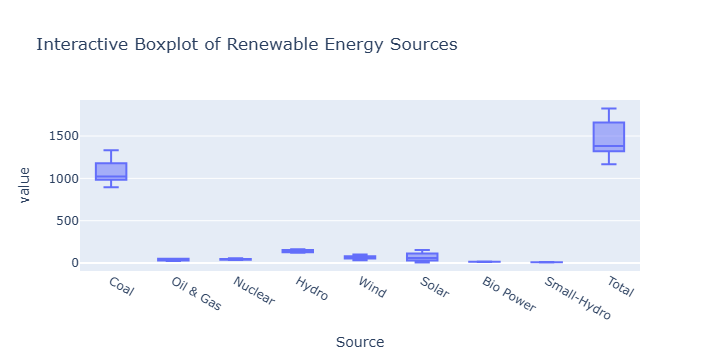

In [122]:
import plotly.express as px

num_df = df.select_dtypes(include="number")

fig = px.box(
    num_df,
    title="Interactive Boxplot of Renewable Energy Sources",
)

fig.show()

No outlier